<a href="https://colab.research.google.com/github/eisbetterthanpi/Kalman-Linear-Attention/blob/main/kla.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# @title hf byte dataset me
!pip install -qU datasets # restart?
import torch
from torch.utils.data import IterableDataset

class StreamDataset(IterableDataset):
    def __init__(self, dataset, seq_len=129, buffer_size=1024):
        self.vocab_size = 256 # utf-8 # self.enc.n_vocab # gpt2:50257
        self.data = iter(dataset)
        self.seq_len, self.buffer_size = seq_len, buffer_size  # must be ≥ seq_len
        self.buffer = []  # token buffer
        self.fill_buffer()

    def fill_buffer(self):
        while len(self.buffer) < self.buffer_size:
            x = next(self.data)
            # print(x)
            self.buffer.extend(x['text'].encode("utf-8"))

    def __iter__(self):
        while True:
            if len(self.buffer) < self.seq_len: self.fill_buffer()
            if len(self.buffer) < self.seq_len: return # raise StopIteration
            x, self.buffer = self.buffer[:self.seq_len], self.buffer[self.seq_len:]
            yield torch.tensor(x, dtype=torch.int32) # uint8 int32

from datasets import load_dataset
name = 'Skylion007/openwebtext' if torch.cuda.is_available() else 'stas/openwebtext-10k'
dataset = load_dataset(name, split="train", streaming=True, revision='refs/convert/parquet', cache_dir="/content/hf")

seq_len = 2**7+1 # 128
buffer_size = seq_len*1
train_data = StreamDataset(dataset, seq_len, buffer_size) # train_data = StreamDataset(dataset["train"], seq_len, buffer_size)
# del dataset

from torch.utils.data.dataloader import DataLoader
batch_size = 64 if torch.cuda.is_available() else 16 #64 512
train_loader = DataLoader(train_data, batch_size=batch_size, pin_memory=True, num_workers=0)
# del train_data
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# https://github.com/facebookresearch/blt/blob/main/bytelatent/tokenizers/blt_tokenizer.py#L137
# def encode(c): return torch.tensor(list(c.encode("utf-8")), dtype=torch.uint8)#, device=device)#.unsqueeze(0)
def encode(c): return torch.tensor(list(c.encode("utf-8")), dtype=torch.int32, device=device).unsqueeze(0)
def decode(x): return bytes(x.tolist()).decode("utf-8", errors='replace') # replace ignore

# for x in train_loader:
#     print(x.shape, x)
#     break
# print(decode(x[0][:64]))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 17.0 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

In [ ]:
# @title causal_conv1d
import torch
import torch.nn as nn
device = 'cuda' if torch.cuda.is_available() else 'cpu'

class CausalConv1d(nn.Conv1d):
    def __init__(self, *args, **kwargs): # in_channels, out_channels, kernel_size, stride=1, padding=0, dilation=1, groups=1, bias=True, padding_mode='zeros', device=None, dtype=None
        super().__init__(*args, **kwargs)

    def forward(self, x, h=None, b_ind=None): # [b,t,d], [b,k-1,in], [b]
        k_1 = self.kernel_size[0]-1

        if b_ind==None: # x:[b,t,d]
            b = x.shape[0]
            if h==None: h = torch.zeros(b, k_1, self.in_channels, device=device) # [b,k-1,d]
            assert h.shape == (b, k_1, self.in_channels)
            x = torch.cat([h, x], dim=1) # [b,k-1+t,d]
            h = x[:,-k_1:] # [b,k-1,d]
            x = super().forward(x.transpose(-2,-1)).transpose(-2,-1) # [b,t,d]
            return x, h # [b,t,d], [b,k-1,d]

        else: # x:[1,b*t,d]
            x = x.squeeze(0)
            b = len(b_ind)-1
            # splits = [i-j for i, j in zip(b_ind[1:], b_ind[:-1])]
            splits = list(b_ind[1:]-b_ind[:-1])
            if h==None: h = torch.zeros(b, k_1, self.in_channels, device=x.device) # [b,k-1,d]
            assert h.shape == (b, k_1, self.in_channels)
            # print('splits', splits)
            # print('conv x,h,b_ind', x.shape, h.shape, b_ind)
            x = torch.cat([xxx for xx in zip(h, torch.split(x, splits, dim=0)) for xxx in xx], dim=0)
            # start_ind = [s+i*k_1 for i,s in enumerate(b_ind)]
            # print(b_ind.device, torch.arange(b+1).device)
            # start_ind = b_ind + torch.arange(b+1)*k_1 # [b+1]
            start_ind = b_ind + torch.arange(b+1, device=b_ind.device)*k_1 # [b+1]
            # print('start_ind', start_ind)
            # print('x', x.shape)
            # print([[st-k_1,st] for st in start_ind[1:]])
            h = torch.stack([x[st-k_1:st] for st in start_ind[1:]], dim=0) # [b,k-1,in]

            x = super().forward(x.T).T
            # x = x[k_1:]

            # print([[st,st+sp] for st,sp in zip(start_ind, splits)])
            x = torch.cat([x[st:st+sp] for st,sp in zip(start_ind, splits)], dim=0) # [b*t,d]
            x = x.unsqueeze(0)
            # print('x,h', x.shape, h.shape)
            return x, h # [1,b*t,d], [b,k-1,in]


# b,t,d = 3,5,4
# k=3
# x = torch.rand(b,t,d, device=device)
# h = torch.rand(b,k-1,d, device=device)
# # b_ind = torch.tensor([0,2,9,b*t])
# b_ind = torch.arange(b+1) * t
# # b_ind = [0,2,9,b*t]
# # b_ind: [0,2,9,15]
# # splits: [2, 7, 6]
# # start_ind: [0, 4, 13, 21]

# # padded in: 222726
# # conv out:   22726
# # true out:   2 7 6
# # h_:             -2:
# conv = CausalConv1d(d, d, k).to(device)
# x0, h0 = conv(x.reshape(1,b*t,d), h, b_ind) # [b*t,d], [b,k-1,in]
# print(x.shape, h.shape)
# x1, h1 = conv(x, h) # [b*t,d], [b,k-1,in]
# x0 = x0.reshape(b,t,d)

# # print(x0[-1,-3:,:5])
# # print(x1[-1,-3:,:5])
# print(abs(x0-x1).sum())
# print(abs(h0-h1).sum())


In [ ]:
# @title parallel_scan
import torch
if not hasattr(torch, "associative_scan"):
    from torch._higher_order_ops.associative_scan import associative_scan
    torch.associative_scan = associative_scan

def parallel_scan(fn, xs, id, c=64): # [tbd,], [1bd,]
    if xs[0].shape[0] % c != 0: # t%c
        return torch.associative_scan(fn, xs, dim=0, combine_mode='generic')
    xs = [x.unflatten(0, (-1,c)) for x in xs] # lcbd
    xs = torch.associative_scan(fn, xs, dim=1, combine_mode='generic') # lcbd
    lx = torch.associative_scan(fn, [x[:,-1] for x in xs], dim=0, combine_mode='generic') # lbd
    pre = [torch.cat([i, x[:-1]], dim=0) for i,x in zip(id, lx)] # lbd
    out = fn([p.unsqueeze(1).expand(-1,c,*(-1,)*(p.ndim-1)) for p in pre], xs) # lcbd
    return [o.flatten(0,1) for o in out] # tbd

# t, d = 12, 5
# l, c = 4, 3
# b=2
# # ab = [torch.randn(t,d) for _ in range(2)]
# # id = [torch.ones(1,d), torch.zeros(1,d)]
# ab = [torch.randn(t,b,d) for _ in range(2)]
# id = torch.tensor([1,0])[:,None,None].expand(-1,b,d).split(1, dim=0) # 1bd
# pcum = parallel_scan(affine, ab, id, c)
# cum = torch.associative_scan(affine, ab, dim=0, combine_mode='generic')

# def mobius(x, y):
#     (a1, b1, c1, d1), (a2, b2, c2, d2) = x, y
#     return a2*a1+b2*c1, a2*b1+b2*d1, c2*a1+d2*c1, c2*b1+d2*d1
#     # a, b, c, d = a2*a1+b2*c1, a2*b1+b2*d1, c2*a1+d2*c1, c2*b1+d2*d1
#     # scale = torch.stack([a.abs(), b.abs(), c.abs(), d.abs()], dim=0).amax(dim=0).clamp(min=1e-8) # guard against exact zero (shouldn't occur)
#     # return a/scale, b/scale, c/scale, d/scale


# # abgd = [torch.randn(t,d) for _ in range(4)]
# abgd = [torch.randn(t,b,d) for _ in range(4)]
# # id = torch.tensor([1,0,0,1])[:,None].expand(-1,d).split(1, dim=0) # 1d
# # id = torch.tensor([1,0,0,1])[:,None,None].expand(-1,b,d).split(1, dim=0) # 1bd
# id = torch.tensor([1.,0.,0.,1.])[:,None,None].expand(-1,b,d).split(1, dim=0) # 1bd

# print(id[0].shape)

# pcum = parallel_scan(mobius, abgd, id, c)
# # pcum = torch.associative_scan(mobius, [x.flatten(-2) for x in abgd], dim=0, combine_mode='generic')
# # pcum = [x.unflatten(-1, (b,d)) for x in pcum]
# cum = torch.associative_scan(mobius, abgd, dim=0, combine_mode='generic')

# for pa,sa in zip(pcum, cum):
#     print(pa[0], sa[0])
#     print(torch.allclose(pa, sa, atol=1e-5))


In [ ]:
# @title Kalman Linear Attention me next
# Kalman Linear Attention: Parallel Bayesian Filtering For Efficient Language Modelling and State Tracking feb 2026 # https://arxiv.org/pdf/2602.10743
import torch
import torch.nn as nn
import torch.nn.functional as F
device = 'cuda' if torch.cuda.is_available() else 'cpu'
if not hasattr(torch, "associative_scan"):
    from torch._higher_order_ops.associative_scan import associative_scan
    torch.associative_scan = associative_scan

def mobius(x, y):
    (a1, b1, c1, d1), (a2, b2, c2, d2) = x, y
    # return a2*a1+b2*c1, a2*b1+b2*d1, c2*a1+d2*c1, c2*b1+d2*d1
    a, b, c, d = a2*a1+b2*c1, a2*b1+b2*d1, c2*a1+d2*c1, c2*b1+d2*d1
    s = (a*a + b*b + c*c + d*d).sqrt().clamp(1e-8)
    return a/s, b/s, c/s, d/s
    params = torch.stack([a, b, c, d])
    mean = params.mean(dim=0)
    std = params.std(dim=0) + 1e-8
    return (a - mean) / std, (b - mean) / std, (c - mean) / std, (d - mean) / std

def affine(x, y): # binary associative operator ⊕ on pairs (f,b): (f2, b2) ⊕ (f1, b1) := (f2f1, f2b1 + b2)
    (f1, g1), (f2, g2) = x, y
    return f2 * f1, f2 * g1 + g2
# ηt = (a¯t^2 + p¯t ⊙ λt-1)^-1 ⊙ a¯t ⊙ ηt-1  +  kt ⊙ Λvt ⊙ vt

@torch.compile()#mode='max-autotune')
class KLALayer(nn.Module):
    def __init__(self, d_model, n_heads=8, d_state=16):
    # def __init__(self, d_model, n_heads=1, d_state=128):
        super().__init__()
        self.d_model, self.n_heads, self.d_state = d_model, n_heads, d_state
        self.conv1d = CausalConv1d(d_model, d_model, kernel_size=4, groups=d_model, bias=True)
        self.act = nn.SiLU()
        self.log_a = nn.Parameter(torch.randn(n_heads, d_state)) # decay rate a > 0
        self.log_p = nn.Parameter(torch.randn(n_heads, d_state)) # process-noise scale p > 0
        self.log_dt = nn.Parameter(torch.randn(n_heads, 1)) # small initial dt >0
        # self.log_lam0 = nn.Parameter(torch.randn(n_heads, d_state)) # log prior precision
        self.log_lam0 = torch.zeros(n_heads, d_state, device=device) # log prior precision
        self.in_proj = nn.Linear(d_model, 5*n_heads*d_state, bias=True)
        self.out_proj = nn.Linear(n_heads*d_state, d_model, bias=True)
        self.norm_q, self.norm_k = nn.RMSNorm(d_state), nn.RMSNorm(d_state)
        self.norm = nn.RMSNorm(n_heads*d_state)

    def _ou_discretise(self): # -> s / hs
        a = F.softplus(self.log_a) # 0.6931
        p = F.softplus(self.log_p) # s / hs
        dt = F.softplus(self.log_dt) # 1 / h1
        a_bar = torch.exp(-a*dt) # s / hs # a¯t (8) # e^-.5=.6
        p_bar = (p**2 / (2*a)) * (1 - torch.exp(-2*a*dt)) # s / hs #  .5/1.4 * (1-.37) = .63/2.8 = .225
        return a_bar, p_bar, a_bar**2 # .6, .23, .36

    def _filter(self, k, v, lv, eta_prev, lam0, a_bar, p_bar, a_bar2): # btd # Parallel Kalman filter (Corollaries 1–2).
        B, T = k.shape[:2] # btd / bthd bhtd
        phi = k**2 * lv # ϕt := kt^2 ⊙ Λ^v_t (Theorem 1) # 0^2 *.7
        alpha, beta = 1 + p_bar * phi, a_bar2 * phi # (17)
        # gamma, delta = p_bar.expand(B,T,-1,-1), a_bar2.expand(B,T,-1,-1) # hd->bthd
        gamma, delta = p_bar.expand(B,T,*(-1,)*p_bar.ndim), a_bar2.expand(B,T,*(-1,)*a_bar2.ndim) # hd->bthd

        alpha, beta, gamma, delta = [x.transpose(0,1) for x in [alpha, beta, gamma, delta]] # tbd
        cum_a, cum_b, cum_c, cum_d = torch.associative_scan(mobius, (alpha, beta, gamma, delta), dim=0, combine_mode='generic')
        # id = torch.tensor([1,0,0,1], device=device)[:,None,None,None].expand(-1,*alpha.shape[1:]).split(1, dim=0) # 1bhd
        # # print(id[0].shape, alpha.shape)
        # cum_a, cum_b, cum_c, cum_d = parallel_scan(mobius, (alpha, beta, gamma, delta), id, c=64)

        Lambda = (cum_a * lam0 + cum_b) / (cum_c * lam0 + cum_d) # tbd (16)
        Lambda_prev = torch.cat([lam0.unsqueeze(0), Lambda[:-1]], dim=0)   # d->1bd cat tbd

        f = a_bar / (a_bar2 + p_bar * Lambda_prev) # tbd (19a) history-dependent forget gate
        g = (k * lv * v).transpose(0,1) # tbd (19b) token evidence
        g[0] = f[0] * eta_prev + g[0]
        _, eta = torch.associative_scan(affine, (f, g), dim=0, combine_mode='generic') # eta: tbd # (Corollary 2) # eta_t = f_t * eta_{t-1} + g_t # information-mean recurrence
        # id = torch.tensor([1,0], device=device)[:,None,None,None].expand(-1,*f.shape[1:]).split(1, dim=0) # 1bhd
        # # print(id[0].shape)
        # _, eta = parallel_scan(affine, (f, g), id, c=64)

        return Lambda, Lambda_prev, f, eta # tbd / tbhd

    def forward(self, x, h=None): # btd
        B, T, _ = x.shape
        if h==None:
            h_conv = None
            lam0 = torch.exp(self.log_lam0).expand(B,-1,-1) # bd
            eta_prev = torch.zeros_like(lam0) # bd
        else: h_conv, eta_prev, lam0 = h

        x, h_conv = self.conv1d(x, h_conv) # [b,t+d_conv-1,xbc]->[b,t,xbc]
        x = self.act(x)

        z, k, v, q, log_lv = self.in_proj(x).chunk(5, dim=-1) # btd
        k, v, q, log_lv = [x.unflatten(-1, (self.n_heads,-1)) for x in [k, v, q, log_lv]] # bt(hd)->bthd
        lv = F.softplus(log_lv) # value precision λ^v > 0, btd # .7
        a_bar, p_bar, a_bar2 = self._ou_discretise() # s / hs # .6, .23, .36

        q, k = self.norm_q(q), self.norm_k(k)
        # k, v = k/torch.norm(k, dim=-1, keepdim=True), v/torch.norm(v, dim=-1, keepdim=True)
        Lambda, Lambda_prev, f, eta = self._filter(k, v, lv, eta_prev, lam0, a_bar, p_bar, a_bar2)

        # mu = eta / Lambda.clamp(1e-6) + torch.randn_like(Lambda) * Lambda.clamp(1e-6).rsqrt() # tbd # posterior mean
        y_mu = eta / Lambda.clamp(1e-6) # Yµ = Q(eta*Λ^-1)
        y_sig = q.transpose(0,1)**2 / Lambda.clamp(1e-6) # YΣ = Q^2 *Λ^-1
        y = y_mu + torch.randn_like(y_sig) * y_sig
        y = (q * y.transpose(0,1)).flatten(2) # btd # posterior-mean readout

# Log marginal likelihood in the paper: -logsumexp s=1 S (log pθ(ot | yt^(s) )) + log S, (22)
        # B, T, HD = mu.shape
        # eps = torch.randn(S, B, T, HD, device=mu.device) # eps = torch.randn(S, *mu.shape, device=mu.device)
        # std = Lambda.clamp(1e-6).rsqrt() # B×T×HD # std = torch.sqrt(1/Lambda)
        # z_samp = mu.unsqueeze(0) + eps * std.unsqueeze(0) # S×B×T×HD # z_t^(s) = µ_t + ε^(s) / √Λ_t ,   ε^(s) ~ N(0, I)
        # y_samp = q.unsqueeze(0) * z_samp # S×B×T×HD # y_t^(s) = q_t ⊙ z_t^(s)
        # y_samp = self.out_proj(y_samp.view(S*B,T,HD))

        y = self.norm(y * self.act(z)) # btd # norm(x)*silu(z) / norm(x*silu(z))
        y_sig = y_sig.transpose(0,1).flatten(2)#.mean(-1)
        return self.out_proj(y), (h_conv, eta[-1], Lambda[-1]), y_sig # btd, (bd,bd)


In [ ]:
# @title klablock model
# Kalman Linear Attention: Parallel Bayesian Filtering For Efficient Language Modelling and State Tracking feb 2026 # https://arxiv.org/pdf/2602.10743
import torch
import torch.nn as nn
import torch.nn.functional as F
device = 'cuda' if torch.cuda.is_available() else 'cpu'

import inspect
class Seq(nn.Sequential):
    def __init__(self, *args):
        super().__init__(*args)
    def forward(self, x, hid=None):
        hidden = []
        y_sig = []
        for i, layer in enumerate(self):
            # x, h = layer(x, hid[i] if hid!=None else None)
            x, h, ysig = layer(x, hid[i] if hid!=None else None)
            hidden.append(h)
            y_sig.append(ysig)
        # return x, hidden
        return x, hidden, y_sig

class KLABlock(nn.Module):
    def __init__(self, d_model, d_state=64, ff_mult=4):
        super().__init__()
        # self.kla = KLALayer(d_model, d_state)
        self.kla = KLALayer(d_model)
        self.norm1, self.norm2 = nn.LayerNorm(d_model), nn.LayerNorm(d_model)
        # self.ffn = nn.Sequential(
        #     nn.Linear(d_model, ff_mult*d_model), nn.GELU(),
        #     nn.Linear(ff_mult*d_model, d_model),
        # )

    def forward(self, x, h=None):
        # x = x + self.kla(self.norm1(x))
        # x_, h = self.kla(self.norm1(x), h)
        x_, h, ysig = self.kla(self.norm1(x), h)
        x = x + x_
        # x = x + self.ffn(self.norm2(x))
        # return x, h
        return x, h, ysig

class KLAModel(nn.Module):
    def __init__(self, vocab_size, d_model, n_layers, d_state=64, max_len=2048):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.blk = Seq(*[KLABlock(d_model, d_state) for _ in range(n_layers)])
        self.norm = nn.LayerNorm(d_model)
        self.out = nn.Linear(d_model, vocab_size, bias=False)
        self.out.weight = self.tok_emb.weight
        emb_std = d_model**-.5
        nn.init.trunc_normal_(self.tok_emb.weight, mean=0, std=emb_std, a=-3*emb_std, b=3*emb_std) # https://github.com/facebookresearch/blt/blob/main/bytelatent/model/local_models.py#L136

    def forward(self, x, h=None):
        x = self.tok_emb(x)
        # x, h = self.blk(x, h)
        x, h, ysig = self.blk(x, h)
        # return self.out(self.norm(x)), h
        # return self.out(x), h
        return self.out(x), h, ysig

# B, T, d_model, d_state, vocab = 2, 128, 256, 64, 1000
B, T, d_model, d_state = 2, 128, 64, 16
try: vocab_size = train_loader.dataset.vocab_size
except NameError: vocab_size = 256
# print(vocab_size)
model = KLAModel(vocab_size, d_model, n_layers=2, d_state=d_state).to(device)
# model = KLAModel(vocab_size, d_model, n_layers=1, d_state=d_state).to(device)
print(sum(p.numel() for p in model.parameters()))
optim = torch.optim.AdamW(model.parameters(), lr=1e-3)

idx = torch.randint(0, vocab_size, (B, T), device=device)
# logits, h = model(idx) # [B, T, vocab]
logits, h, y_sig = model(idx) # [B, T, vocab]

loss = F.cross_entropy(logits[:,:-1].reshape(-1, vocab_size), idx [:, 1: ].reshape(-1))
loss.backward()
print(f"logits: {logits.shape}  loss: {loss.item():.4f}  (backward ok)")


# 118658p
# this is what is from in the Ousbrenned Milays. Lecont, gualt seem awertrup�
# 700 time: 11.10176706314087 11.137237310409546
# train 1.926253080368042
# this is whatev Ogis soung or the Weators of the silture and for cymers beep

# this is what the revolue that Islands the censor so other prowoment. Educate
# 64000 time: 10.289371252059937 10.868518272787332
# train 1.4133729934692383
# this is what Parkark pingle its delete of his pore know the children who lik


# d64,2lyr,
# cpu associative_scan 33s # c64 40sec # c32 38sec # c16 40sec # c8 39sec
# gpu 9.1
# compile 1.7?
# c8 10s c16 10.3 c32 10.4? c6410.3 compile 2.7


118224


W0511 06:51:09.643000 2828 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode


logits: torch.Size([2, 128, 256])  loss: 5.7991  (backward ok)


In [ ]:
m = model.blk[0].kla
# print(m.log_a, m.log_p, m.log_dt, m.log_lambda0)
print(m.log_a, m.log_p, m.log_dt)

Parameter containing:
tensor([[-0.8561,  0.5733, -0.3680, -0.5310, -0.3315, -0.7467, -0.7764,  0.5265,
         -0.9839, -0.8839,  0.6842, -0.0108, -0.8792,  0.7375, -0.1667, -0.8119,
         -0.2034,  0.1267, -0.7410, -0.5761,  0.0072, -0.6272,  0.3230, -0.4124,
          0.5087,  0.0305,  0.5226, -0.0154, -0.9245,  0.6680,  0.1400, -1.1184,
         -0.4916,  0.0551, -0.4712, -1.3700, -1.0600, -1.1444,  0.0309,  0.5265,
          0.0063,  0.1972,  0.3253,  0.0950, -0.6483,  0.6936, -0.8425, -0.4897,
          0.0367,  0.4552,  0.6466,  0.6916,  0.5394,  0.1620, -1.4269, -1.4348,
         -0.3868, -0.7072,  0.7091, -0.1224,  0.4602, -0.6755,  0.4821,  0.4403,
          0.4843, -0.7953, -1.2608,  0.2778, -0.0921, -0.6848,  0.4010, -0.1614,
          0.1947,  0.0228, -0.8020,  0.7145,  0.4198, -0.4035,  0.2932, -0.3848,
          0.4470,  0.2437, -0.6483, -0.5700,  0.4451, -0.6258, -1.0125,  0.4649,
         -0.4218, -0.0524, -0.1661, -0.3226, -0.5026,  1.0984,  0.0186,  0.8085,
      

In [ ]:
# @title wandb
!pip install -q wandb
import wandb # https://docs.wandb.ai/quickstart
wandb.login(key='487a2109e55dce4e13fc70681781de9f50f27be7')
try: run.finish()
except NameError: pass
run = wandb.init(project="kla", config={"model": "kla",}) #
# run = wandb.init(project="mamba", config={"model": "kla",}) #

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: bobdole to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
# @title train generate
import torch
from torch.nn import functional as F
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
# scaler = torch.GradScaler()

# # https://www.comet.com/site/blog/perplexity-for-llm-evaluation/
# def Perplexity(logits, target): # [b,t,vocab_size], [b,t]
#     log_probs = F.log_softmax(logits, dim=-1)
#     nll = -log_probs.gather(dim=-1, index=target.unsqueeze(-1)).squeeze(-1) # [b,t]
#     perplexity = nll.mean().exp()
#     return perplexity

import time
def strain(model, dataloader, optim, scheduler=None): # train function with automatic mixed precision
    start = begin = time.time()
    model.train()
    for i, x in enumerate(dataloader):
        x, y = x[:,:-1].to(device), x[:,1:].to(device)
        # with torch.autocast(device_type=device, dtype=torch.bfloat16):
        # logits, _ = model(x) #output = [batch size, trg len - 1, output dim]
        logits, _, _ = model(x) #output = [batch size, trg len - 1, output dim]
        loss = F.cross_entropy(logits.flatten(0,1), y.flatten().to(int)) # [b*t,d], [b*t]
        optim.zero_grad()
        loss.backward()
        optim.step()
        if scheduler is not None: scheduler.step()
        if i % 100 == 0:
            print(i, 'time:',time.time() - start, (time.time()-begin)/max(1,i//100))
            print('train', loss.item())
            print(generate(model, "this is what"))
            model.train()
            # perplexity = Perplexity(logits.detach(), y).item()
            start = time.time()
        try: wandb.log({"train loss": loss.item()})
        except NameError: pass

def generate(model, context, max_steps=64, temperature=1):
    x = encode(context)#.to(device)
    model.eval()
    hid=None
    for n in range(max_steps):
        # with torch.no_grad(): out, hid = model(x if hid==None else x[:,-1:], hid)
        with torch.no_grad(): out, hid, y_sig = model(x if hid==None else x[:,-1:], hid)
        # with torch.no_grad(): out, hid = model(x, hid)
        out = out[:,-1] # get logit for last character
        out = F.softmax(out/temperature, dim=-1) # vocab_size to char
        ix = torch.multinomial(out, num_samples=1) # rand sample by output distribution
        x = torch.cat([x, ix], dim=1)
    completion = decode(x.squeeze(0))
    return completion

# scheduler = get_cosine_schedule_with_warmup(optim, num_warmup_steps=400, num_training_steps=40000) # https://docs.pytorch.org/torchtune/0.2/generated/torchtune.modules.get_cosine_schedule_with_warmup.html
# import time
# start = begin = time.time()
for i in range(1):
    # train_loss = strain(model, train_loader, optim, scheduler=None)
    strain(model, train_loader, optim, scheduler=None)
    # strain(model, train_loader, optim, scheduler=scheduler)
    # print(generate(model, "this is what"))
    # print(i, 'time:',time.time() - start, (time.time()-begin)/(i+1))
    # start = time.time()


Streaming output truncated to the last 5000 lines.
148000 time: 1.8178856372833252 2.115875225131576
train 1.4775059223175049
this is what he treignations of discovitable poophong time and appropriate t
148100 time: 2.0930023193359375 2.115949946589602
train 1.3867521286010742
this is what’s worried by it: B.@, 10, Hungen, arrestinious or clarketent 
148200 time: 2.503925323486328 2.1163436137391165
train 1.3741334676742554
this is what he talks it is greatent running.”Creed sehes or two topic sai
148300 time: 1.7890739440917969 2.1162123961458317
train 1.4677141904830933
this is what wasn’t Near. It after at a Russian ‘The regulate legislatio
148400 time: 1.8288531303405762 2.1161084933422325
train 1.4658446311950684
this is what the house pay from two fay before the cape news for each very l
148500 time: 1.7329413890838623 2.115938345270125
train 1.5723687410354614
this is what nonetheless now utponees developers this secret will show allow
148600 time: 1.8083980083465576 2.115829161

In [ ]:
# @title save/load
from google.colab import drive
drive.mount('/content/drive')
folder='/content/drive/MyDrive/jepa/'
device = "cuda" if torch.cuda.is_available() else "cpu"

# !gdown 1DWHL6q_AU5eIEkpnaIfs9gaL2-E7qsgJ -O kla.pkl # B2

# # modelsd, optimsd = torch.load(folder+'kla.pkl', map_location=device).values()
# modelsd, optimsd = torch.load('kla.pkl', map_location=device).values()
# model.load_state_dict(modelsd, strict=False)
# optim.load_state_dict(optimsd)

In [ ]:
checkpoint = {'model': model.state_dict(), 'optimizer': optim.state_dict()}
torch.save(checkpoint, folder+'kla.pkl')
# torch.save(checkpoint, 'kla.pkl')

In [ ]:
# title gdown
import pickle
!gdown 1DWHL6q_AU5eIEkpnaIfs9gaL2-E7qsgJ -O kla.pkl # B2
# with open('buffer.pkl', 'rb') as f: buffer = pickle.load(f)

In [ ]:
def encode(c): return torch.tensor(list(c.encode("utf-8")), dtype=torch.int32, device=device).unsqueeze(0)
def decode(x): return bytes(x.tolist()).decode("utf-8", errors='replace') # replace ignore

context = '''In complex analysis, Möbius transformations are typically represented by matrices where the determinant $ad - bc = 1$. This is the most "mathematically honest" way to stabilize'''
x = encode(context)#.to(device)
model.eval()
# hid=None
# for n in range(max_steps):
#     with torch.no_grad(): out, hid = model(x if hid==None else x[:,-1:], hid)
#     # with torch.no_grad(): out, hid = model(x, hid)
#     out = out[:,-1] # get logit for last character
#     out = F.softmax(out/temperature, dim=-1) # vocab_size to char
#     ix = torch.multinomial(out, num_samples=1) # rand sample by output distribution
#     x = torch.cat([x, ix], dim=1)
out, h, y_sig = model(x)
out = F.softmax(out/1, dim=-1)#[0] # vocab_size to char
# print(out.shape)
out = out[:,-1] # get logit for last character
x = torch.multinomial(out, num_samples=1) # rand sample by output distribution

completion = decode(x.squeeze(0))
print(completion)

]


In [ ]:
print(generate(model, "this is what"))


this is whatos.tw.mahuybbeeohor-m��t erlnon eyenoioradabouoHt �etrneegthog


In [ ]:
# print(ysig.shape) # nlyr[]
print(ysig[0].shape) # nlyr[1ts]

torch.Size([1, 177, 128])


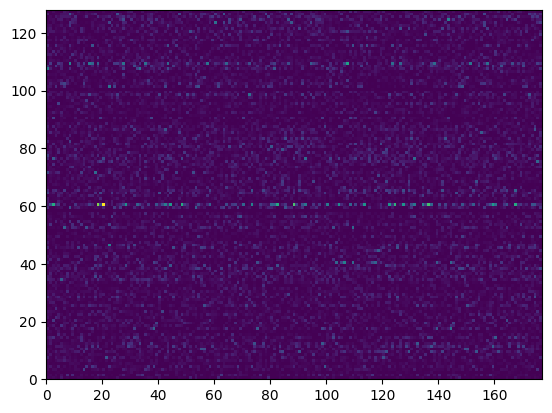

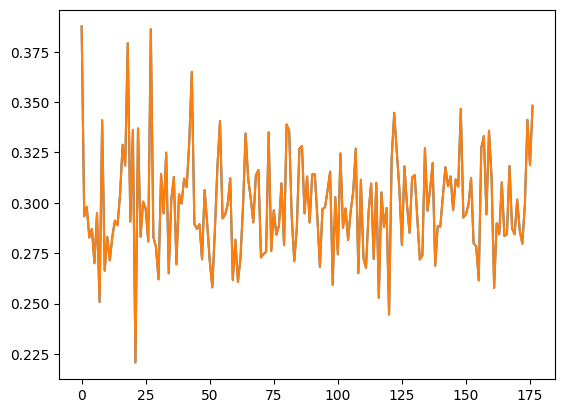

In [ ]:
import matplotlib.pyplot as plt
ysig = y_sig[0]
plt.pcolormesh(ysig[0].detach().T)
plt.show()
plt.plot(ysig[0].detach().mean(-1))
plt.plot(ysig[0].detach().mean(-1))
plt.show()

In [ ]:
def plot_text_weights(text, weights):
    # Normalize weights to [0, 255] for grayscale or color mapping
    max_w = max(weights) if max(weights) > 0 else 1
    html_str = "<div style='font-family: monospace; white-space: pre;'>"
    for char, w in zip(text, weights):
        alpha = w / max_w
        # Using a yellow highlight (rgba)
        html_str += f"<span style='background-color: rgba(255, 255, 0, {alpha:.2f})'>{char}</span>"
    html_str += "</div>"
    return html_str

import matplotlib.pyplot as plt
import seaborn as sns

def visualize_matplotlib(text, weights):
    chars = list(text)
    data = [weights]
    plt.figure(figsize=(len(chars) * 0.3, 1.2))
    sns.heatmap(data, annot=True, xticklabels=chars, yticklabels=False,  cmap="YlGnBu", cbar=False, fmt=".2f")
    plt.xticks(rotation=0)
    plt.show()


## save

In [ ]:
# @title MultiHeadKLALayer


    def forward(self, x, h): # B×T×d_model # (eta_prev, lam0) B×H×D each
        """
        out       : B×T×d_model
        new_h     : (eta_last, lam_last)  each B×H×D — correct recurrent state
        extras    : dict with mu, Lambda, q (B×T×H*D) if return_extras, plus mu_smooth/sigma_smooth (T×BH×D) if return_smooth.
        Note: to compute eq (22) LML pass extras['mu'], extras['Lambda'],
        extras['q'] to kla_log_marginal_likelihood() at the model level.
        """
        B, T, _ = x.shape
        H, D = self.n_heads, self.d_state
        BH = B * H
        if h is None:
            lam0 = torch.exp(self.log_lam0).unsqueeze(0).expand(B,-1,-1) # H×D-> B×H×D
            eta_prev = torch.zeros_like(lam0)
        else:
            eta_prev, lam0 = h                            # B×H×D each

        lam0_flat     = lam0.reshape(BH, D)
        eta_prev_flat = eta_prev.reshape(BH, D)

        # ── Project and split ──────────────────────────────────────────────────
        # B×T×(H*5*D) → B×T×H×5×D → 5 × B×T×H×D
        proj = self.in_proj(x).view(B, T, H, 5, D)
        k, v, q, log_lv, gate_raw = proj.unbind(dim=3)    # each B×T×H×D
        lv = F.softplus(log_lv)

        a_bar, p_bar, a_bar2 = self._ou_discretise(B)      # BH×D each


    # def _to_BHtD B×T×H×D → (B*H)×T×D
    # def _from_BHtD (B*H)×T×D → B×T×(H*D)


        Lambda, Lambda_prev, f, eta = self._filter(
            self._to_BHtD(k, B),
            self._to_BHtD(v, B),
            self._to_BHtD(lv, B),
            eta_prev_flat, lam0_flat,
            a_bar, p_bar, a_bar2)
        # All T×BH×D

        # ── Posterior readouts ─────────────────────────────────────────────────
        qt    = self._to_BHtD(q, B).permute(1,0,2)         # T×BH×D
        mu    = eta / Lambda.clamp(1e-6)                    # T×BH×D
        Y_mu  = qt * mu                                     # E[q⊙z | v_{1:t}]
        Y_sig = qt**2 / Lambda.clamp(1e-6)                  # Var[q⊙z | v_{1:t}]

        # ── Multiplicative gate ────────────────────────────────────────────────
        # Base: Y_µ ⊙ silu(gate)
        # Confidence-weighted variant (uncomment to use Y_Σ):
        #   conf  = torch.sigmoid(-Y_sig)           # ≈1 when posterior is tight
        #   y_out = Y_mu * conf * F.silu(gate_t)
        gate_t = self._to_BHtD(gate_raw, B).permute(1,0,2) # T×BH×D
        y_out  = Y_mu * F.silu(gate_t)

        # ── Project back to d_model ────────────────────────────────────────────
        # T×BH×D → BH×T×D → B×T×(H*D) → B×T×d_model
        out = self.out_proj(self._from_BHtD(y_out.permute(1,0,2), B))

        # ── New recurrent state (FIXED) ───────────────────────────────────────
        new_h = (eta[-1].reshape(B, H, D), Lambda[-1].reshape(B, H, D))
        if not (return_extras or return_smooth):
            return out, new_h

        # ── Optional extras ────────────────────────────────────────────────────
        # Reshape T×BH×D → B×T×(H*D) for caller convenience
        def thd_to_btHD(t):
            return self._from_BHtD(t.permute(1,0,2), B)     # B×T×(H*D)

        extras = {}
        if return_extras:
            extras['mu'] = thd_to_btHD(mu)              # posterior means
            extras['Lambda'] = thd_to_btHD(Lambda)          # posterior precisions
            extras['q'] = q.reshape(B, T, H*D)         # query projections
            extras['Y_sig'] = thd_to_btHD(Y_sig)           # posterior variances

        if return_smooth:
            mu_s, sig_s = self._rts_smooth(eta, Lambda, a_bar, p_bar)
            extras['mu_smooth']    = mu_s    # T×BH×D  (keep this form for RTS)
            extras['sigma_smooth'] = sig_s
        return out, new_h, extras


In [ ]:
# @title Kalman Linear Attention me next
# Kalman Linear Attention: Parallel Bayesian Filtering For Efficient Language Modelling and State Tracking feb 2026 # https://arxiv.org/pdf/2602.10743
import torch
import torch.nn as nn
import torch.nn.functional as F
device = 'cuda' if torch.cuda.is_available() else 'cpu'
if not hasattr(torch, "associative_scan"):
    from torch._higher_order_ops.associative_scan import associative_scan
    torch.associative_scan = associative_scan

def mobius(x, y):
    (a1, b1, c1, d1), (a2, b2, c2, d2) = x, y
    # return a2*a1+b2*c1, a2*b1+b2*d1, c2*a1+d2*c1, c2*b1+d2*d1
    a, b, c, d = a2*a1+b2*c1, a2*b1+b2*d1, c2*a1+d2*c1, c2*b1+d2*d1
    # s = torch.stack([a.abs(), b.abs(), c.abs(), d.abs()], dim=0).amax(dim=0).clamp(min=1e-8) # guard against exact zero (shouldn't occur)
    # s = (a*d-b*c).abs().sqrt().clamp(1e-8) # determinant
    # print('det', s[0])
    s = (a*a + b*b + c*c + d*d).sqrt().clamp(1e-8)
    return a/s, b/s, c/s, d/s

def affine(x, y): # binary associative operator ⊕ on pairs (f,b): (f2, b2) ⊕ (f1, b1) := (f2f1, f2b1 + b2)
    (f1, g1), (f2, g2) = x, y
    return f2 * f1, f2 * g1 + g2
# ηt = (a¯t^2 + p¯t ⊙ λt-1)^-1 ⊙ a¯t ⊙ ηt-1  +  kt ⊙ Λvt ⊙ vt

class KLALayer(nn.Module):
    def __init__(self, d_model, n_heads=8, d_state=8):
        super().__init__()
        self.d_model, self.n_heads, self.d_state = d_model, n_heads, d_state
        self.log_a = nn.Parameter(torch.randn(n_heads, d_state)) # decay rate a > 0
        self.log_p = nn.Parameter(torch.randn(n_heads, d_state)) # process-noise scale p > 0
        self.log_dt = nn.Parameter(torch.randn(n_heads, 1)) # small initial dt >0
        self.log_lam0 = nn.Parameter(torch.randn(n_heads, d_state)) # log prior precision
        self.in_proj = nn.Linear(d_model, 4*n_heads*d_state, bias=True)
        self.out_proj = nn.Linear(n_heads*d_state, d_model, bias=True)

    def _ou_discretise(self): # -> s / hs
        a = F.softplus(self.log_a) # 0.6931
        p = F.softplus(self.log_p) # s / hs
        dt = F.softplus(self.log_dt) # 1 / h1
        a_bar = torch.exp(-a*dt) # s / hs # a¯t (8) # e^-.5=.6
        p_bar = (p**2 / (2*a)) * (1 - torch.exp(-2*a*dt)) # s / hs #  .5/1.4 * (1-.37) = .63/2.8 = .225
        return a_bar, p_bar, a_bar**2 # .6, .23, .36

    def _filter(self, k, v, lv, eta_prev, lam0, a_bar, p_bar, a_bar2): # btd # Parallel Kalman filter (Corollaries 1–2).
        B, T = k.shape[:2] # btd / bthd bhtd
        phi = k**2 * lv # ϕt := kt^2 ⊙ Λ^v_t (Theorem 1) # 0^2 *.7
        alpha = 1 + p_bar * phi # (17) # 1+.23*.0=1
        beta = a_bar2 * phi # .36*.0
        gamma = p_bar.expand(B,T,-1,-1) # d->btd # .23
        delta = a_bar2.expand(B,T,-1,-1) # .36

        alpha, beta, gamma, delta = [x.transpose(0,1) for x in [alpha, beta, gamma, delta]] # tbd
        # cum_a, cum_b, cum_c, cum_d = torch.associative_scan(_mobius_combine, (alpha, beta, gamma, delta), dim=0) # parallel precision scan (Corollary 1)
        cum_a, cum_b, cum_c, cum_d = torch.associative_scan(_mobius_combine, (alpha, beta, gamma, delta), dim=0, combine_mode='generic')
        Lambda = (cum_a * lam0 + cum_b) / (cum_c * lam0 + cum_d) # tbd (16)
        Lambda_prev = torch.cat([lam0.unsqueeze(0), Lambda[:-1]], dim=0)   # d->1bd cat tbd

        f = a_bar / (a_bar2 + p_bar * Lambda_prev) # tbd (19a) history-dependent forget gate
        k, v, lv = [x.transpose(0,1) for x in [k, v, lv]] # tbd
        g = k * lv * v # tbd (19b) token evidence
        g[0] = f[0] * eta_prev + g[0]
        # _, eta = torch.associative_scan(_affine_combine, (f, g), dim=0) # eta: tbd
        _, eta = torch.associative_scan(_affine_combine, (f, g), dim=0, combine_mode='generic') # eta: tbd # (Corollary 2) # eta_t = f_t * eta_{t-1} + g_t # information-mean recurrence
        return Lambda, Lambda_prev, f, eta # tbd / tbhd

    def forward(self, x, h=None): # btd
        B, T, _ = x.shape
        if h==None:
            lam0 = torch.exp(self.log_lam0).expand(B,-1,-1) # bd
            eta_prev = torch.zeros_like(lam0) # bd
        else: eta_prev, lam0 = h
        k, v, q, log_lv = self.in_proj(x).chunk(4, dim=-1) # btd
        k, v, q, log_lv = [x.unflatten(-1, (self.n_heads, -1)) for x in [k, v, q, log_lv]] # bt(hd)->bthd
        lv = F.softplus(log_lv) # value precision λ^v > 0, btd # .7
        a_bar, p_bar, a_bar2 = self._ou_discretise() # s / hs # .6, .23, .36

        # k, v = k/torch.norm(k, dim=-1, keepdim=True), v/torch.norm(v, dim=-1, keepdim=True)
        Lambda, Lambda_prev, f, eta = self._filter(k, v, lv, eta_prev, lam0, a_bar, p_bar, a_bar2)

        mu = eta / Lambda.clamp(1e-6) # tbd # posterior mean
        y = (q * mu.transpose(0,1)).flatten(2) # btd # posterior-mean readout
        # y_sig = q**2 / Lambda.clamp(1e-6) # Var[q⊙z | v_{1:t}] # Y_Σ  = q² ⊙ Σ = q²/Λ   posterior-variance readout

        # B, T, HD = mu.shape
        # eps = torch.randn(S, B, T, HD, device=mu.device) # eps = torch.randn(S, *mu.shape, device=mu.device)
        # std = Lambda.clamp(min=1e-6).rsqrt() # B×T×HD # std = torch.sqrt(1/Lambda)
        # z_samp = mu.unsqueeze(0) + eps * std.unsqueeze(0) # S×B×T×HD # z_t^(s) = µ_t + ε^(s) / √Λ_t ,   ε^(s) ~ N(0, I)
        # y_samp = q.unsqueeze(0) * z_samp # S×B×T×HD # y_t^(s) = q_t ⊙ z_t^(s)
        # y_samp = self.out_proj(y_samp.view(S*B,T,HD))

        return self.out_proj(y), (eta[-1], Lambda[-1]) # btd, (bd,bd)


In [ ]:
# @title kla
# Kalman Linear Attention: Parallel Bayesian Filtering For Efficient Language Modelling and State Tracking feb 2026 # https://arxiv.org/pdf/2602.10743
"""
Generative model (diagonal, per-head):
  z_t | z_{t-1}  ~  N( a_bar * z_{t-1},  p_bar )          [OU prior]
  v_t | z_t      ~  N( k_t  * z_t,        lv_t^{-1} )      [obs likelihood]
"""
import torch
import torch.nn as nn
import torch.nn.functional as F
if not hasattr(torch, "associative_scan"):
    from torch._higher_order_ops.associative_scan import associative_scan
    torch.associative_scan = associative_scan

def _mobius_combine(x, y):
    """Compose two Möbius transforms represented as (a,b,c,d) tuples.
    Each transform maps  L -> (a*L + b) / (c*L + d).
    Composition (first x, then y) corresponds to matrix product  M_y @ M_x.
    """
    a1, b1, c1, d1 = x
    a2, b2, c2, d2 = y
    return a2*a1+b2*c1, a2*b1+b2*d1, c2*a1+d2*c1, c2*b1+d2*d1

def _affine_combine(x, y):
    """Compose two affine maps  s -> f*s + g.
    (f2, g2) o (f1, g1)  maps  s -> f2*(f1*s + g1) + g2 = f2*f1*s + (f2*g1 + g2).
    """
    f1, g1 = x
    f2, g2 = y
    return f2 * f1, f2 * g1 + g2

class KLALayer(nn.Module):
    def __init__(self, d_model, d_state=64):
        super().__init__()
        self.d_model, self.d_state = d_model, d_state
        # self.log_a = nn.Parameter(torch.randn(d_state)) # decay rate a > 0
        # self.log_p = nn.Parameter(torch.randn(d_state)) # process-noise scale p > 0
        self.log_a = nn.Parameter(torch.empty(d_state).normal_(-1)) # decay rate a > 0
        self.log_p = nn.Parameter(torch.empty(d_state).normal_(-1)) # process-noise scale p > 0
        # self.log_dt = nn.Parameter(torch.full((1,), -1.)) # small initial dt >0
        self.log_dt = nn.Parameter(torch.tensor([-1.])) # small initial dt >0
        self.in_proj  = nn.Linear(d_model, 4*d_state, bias=True)
        self.out_proj = nn.Linear(d_state, d_model, bias=True)
        self.log_lambda0 = nn.Parameter(torch.randn(d_state)) # log prior precision
        nn.init.trunc_normal_(self.in_proj.weight, mean=0, std=.02) # https://github.com/facebookresearch/blt/blob/main/bytelatent/model/local_models.py#L136

    def _ou_discretise(self):
        a = F.softplus(self.log_a) # 0.6931
        p = F.softplus(self.log_p) #
        dt = F.softplus(self.log_dt) #
        a_bar = torch.exp(-a*dt) # d # a¯t (8) # e^-.5=.6
        p_bar = (p**2 / (2*a)) * (1 - torch.exp(-2*a*dt)) # d #  .5/1.4 * (1-.37) = .63/2.8 = .225
        return a_bar, p_bar, a_bar**2 # .6, .23, .36

    def forward(self, x, h=None): # btd
        B, T, _ = x.shape
        if h==None:
            lam0 = torch.exp(self.log_lambda0).expand(B,-1) # bd
            eta_prev = torch.zeros_like(lam0) # bd
        else:
            eta_prev, lam0 = h
        k, v, q, log_lv = self.in_proj(x).chunk(4, dim=-1) # btd

        lv = F.softplus(log_lv) # value precision λ^v > 0, btd # .7
        a_bar, p_bar, a_bar2 = self._ou_discretise() # d # .6, .23, .36
        # ---- per-step Möbius elements (Theorem 1) -------------------
        phi = k**2 * lv # ϕt := kt^2 ⊙ Λ^v_t (Theorem 1) # 0^2 *.7
        alpha = 1 + p_bar * phi # (17) # 1+.23*.0=1
        beta = a_bar2 * phi # .36*.0
        gamma = p_bar.expand(B,T,-1) # d->btd # .23
        delta = a_bar2.expand(B,T,-1) # .36
        alpha, beta, gamma, delta = [x.permute(1,0,2) for x in [alpha, beta, gamma, delta]] # tbd

        # cum_a, cum_b, cum_c, cum_d = torch.associative_scan(_mobius_combine, (alpha, beta, gamma, delta), dim=0) # parallel precision scan (Corollary 1)
        cum_a, cum_b, cum_c, cum_d = torch.associative_scan(_mobius_combine, (alpha, beta, gamma, delta), dim=0, combine_mode='generic')
        Lambda = (cum_a * lam0 + cum_b) / (cum_c * lam0 + cum_d) # tbd (16)
        Lambda_prev = torch.cat([lam0.unsqueeze(0), Lambda[:-1]], dim=0)   # d->1bd cat tbd

        f = a_bar / (a_bar2 + p_bar * Lambda_prev) # tbd (19a) history-dependent forget gate
        k, v, lv = [x.permute(1,0,2) for x in [k, v, lv]] # tbd
        g = k * lv * v # tbd (19b) token evidence
        g[0] += f[0] * eta_prev

        # With eta_0 = 0:  eta_t = G_cum[t]
        # _, eta = torch.associative_scan(_affine_combine, (f, g), dim=0) # eta: tbd
        _, eta = torch.associative_scan(_affine_combine, (f, g), dim=0, combine_mode='generic') # eta: tbd # (Corollary 2) # eta_t = f_t * eta_{t-1} + g_t # information-mean recurrence
        mu = eta / Lambda # tbd # posterior mean
        y = q * mu.permute(1,0,2) # btd # posterior-mean readout
        return self.out_proj(y), (eta_prev, Lambda[-1]) # btd, (bd,bd)



In [ ]:
# @title rts

    def _rts_smooth(self, eta, Lambda, a_bar, p_bar): # tbd
        """
        Forward filtered:   z_t | v_{1:t} ~ N(µ_t, Σ_t)   where Σ_t = 1/Λ_t
        RTS smoothed:       z_t | v_{1:T} ~ N(µ_tˢ, Σ_tˢ)

        Terminal seed trick:
            Replace position T-1 with (f=0, g=terminal_value), flip the
            sequence, run a forward _affine_combine scan, flip back.
            The (0, v) seed ensures the forward scan "starts" from terminal_value
            regardless of what came before it — equivalent to initialising a
            right-to-left scan at the filtered estimate at T.
        """
        Sigma = 1 / Lambda.clamp(1e-6)
        mu = eta * Sigma
        J = a_bar / (a_bar2 + p_bar * Lambda) # Smoother gain J_t = ā Σ_t / Σ̂_{t+1} = ā / (ā² + p̄ Λ_t) # mirrors forget gate f_t but uses filtered Λ_t, not Λ_{t-1}
        Sigma_pred = a_bar2 * Sigma + p_bar # Σ̂_{t+1}  T×B×d

        def _rev_scan(f_seq, g_seq, terminal_g):
            # Seed terminal position with (0, terminal_g), then flip→scan→flip
            f_ = torch.cat([f_seq[:-1], torch.zeros_like(f_seq[-1:])], 0)
            g_ = torch.cat([g_seq[:-1], terminal_g], 0)
            _, out_r = torch.associative_scan(_affine_combine, (f_.flip(0), g_.flip(0)), dim=0, combine_mode='generic')
            return out_r.flip(0)   # T×B×d

        mu_smooth = _rev_scan(J, (1-J*a_bar) * mu, mu[-1:]) # µ_{T-1}^s = µ_{T-1}
        Sigma_smooth = _rev_scan(J**2, Sigma - J**2 * Sigma_pred, Sigma[-1:]) # Σ_{T-1}^s = Σ_{T-1}
            # µ_tˢ = J_t  µ_{t+1}ˢ + (1 - J_t ā) µ_t         mean
            # Σ_tˢ = J_t² Σ_{t+1}ˢ + (Σ_t - J_t² Σ̂_{t+1})   variance
        return mu_smooth, Sigma_smooth # tbd


    def _log_marginal_likelihood(self, v, k, lv, eta, Lambda_prev, f, eta_prev, a_bar):
        eta0 = torch.cat([eta_prev.unsqueeze(0), eta[:-1]], 0) # η_{t-1}
        Lambda_hat = (f * Lambda_prev / a_bar).clamp(1e-6) # Λ̂_t = f_t Λ_{t-1} / ā # predicted state precision; from f_t = ā Λ̂_t/Λ_{t-1}
        mu_hat = a_bar * eta0 / Lambda_prev.clamp(1e-6) # µ̂_t = ā µ_{t-1} # predicted state mean

        vt, kt, lvt = v.permute(1,0,2), k.permute(1,0,2), lv.permute(1,0,2)
        innov  = vt - kt * mu_hat # δ_t = v_t - k_t µ̂_t
        S = kt**2 / Lambda_hat + 1 / lvt.clamp(1e-6) # S_t = k_t²/Λ̂_t + 1/λᵛ_t # innovation variance
        log_p = -.5 * (math.log(2*math.pi) + S.log() + innov**2 / S)
        # log p(v_{1:T}) = Σ_t log N(v_t ; k_t µ̂_t, S_t)
        return log_p.sum(dim=(0,2)).mean()

    def forward(self, x, h=None):
        B, T, _ = x.shape
        if h is None:
            lam0 = torch.exp(self.log_lam0).expand(B,-1).contiguous()
            eta_prev = torch.zeros_like(lam0)
        else:
            eta_prev, lam0 = h
        k, v, q, log_lv, gate_raw = self.in_proj(x).chunk(5, dim=-1)
        lv = F.softplus(log_lv)
        a_bar, p_bar, a_bar2 = self._ou_discretise()


        Lambda, Lambda_prev, f, eta = self._filter(k, v, lv, eta_prev, lam0, a_bar, p_bar, a_bar2)
        # ── Posterior readouts ─────────────────────────────────────────────────

        q = q.permute(1,0,2)
        mu = eta / Lambda.clamp(1e-6) # T×B×d  posterior mean
        Y_mu = q * mu # E[q⊙z | v_{1:t}] # Y_µ  = q ⊙ µ # posterior-mean readout  (Eq. 20)
        Y_sig = q**2 / Lambda.clamp(1e-6) # Var[q⊙z | v_{1:t}] # Y_Σ  = q² ⊙ Σ = q²/Λ   posterior-variance readout

        # confidence = torch.sigmoid(-Y_sig) # ≈1 when Σ is small (certain)
        # y_out = Y_mu * confidence * F.silu(gate_raw.permute(1,0,2))
        y_out = Y_mu * F.silu(gate_raw.permute(1,0,2)) # tbd # y = Y_µ ⊙ silu(gate)
        out = self.out_proj(y_out.permute(1,0,2))

        lml = self._log_marginal_likelihood(v, k, lv, eta, Lambda_prev, f, eta_prev, a_bar)
        mu_s, sig_s = self._rts_smooth(eta, Lambda, a_bar, p_bar) # tbd # E[z_t | v_{1:T}], Var[z_t | v_{1:T}]
        return out, (eta[-1], Lambda[-1]), (lml, mu_s, sig_s)


In [ ]:
# @title kla_log_marginal_likelihood

# Log marginal likelihood in the paper: -logsumexp s=1 S (log pθ(ot | yt^(s) )) + log S, (22)
def kla_log_marginal_likelihood(
    mu, Lambda,   # B×T×(H*D)  posterior precisions
    q,   # B×T×(H*D)  query projections
    targets,   # B×T         next-token indices
    # out_proj, lm_head,
    S=8): # log p(o_t | v_{1:t}) ≈ logsumexp_s log p_θ(o_t | y_t^(s)) - log S
    # For S>1 the bound tightens (IWAE-style).
    # tile the batch by S, single forward through out_proj+lm_head, reshape and logsumexp — no Python loop over samples.
    B, T, HD = mu.shape
    eps = torch.randn(S, B, T, HD, device=mu.device) # eps = torch.randn(S, *mu.shape, device=mu.device)
    std = Lambda.clamp(min=1e-6).rsqrt() # B×T×HD # std = torch.sqrt(1/Lambda)
    z_samp = mu.unsqueeze(0) + eps * std.unsqueeze(0) # S×B×T×HD # z_t^(s) = µ_t + ε^(s) / √Λ_t ,   ε^(s) ~ N(0, I)
    y_samp = q.unsqueeze(0) * z_samp # S×B×T×HD # y_t^(s) = q_t ⊙ z_t^(s)
    # logits = lm_head(out_proj(y_samp)) # Tile: (S*B)×T×HD  →  out_proj  →  lm_head  →  (S*B)×T×vocab

    # log p(o_t | y_t^(s)): (S*B)×T  →  S×B×T
    log_probs = -F.cross_entropy(logits.flatten(0,2), targets.expand(S,-1,-1).flatten(), reduction='none').view(S,T,B)
    lml = -torch.logsumexp(log_probs, dim=0).mean() + math.log(S) # L_lml = -logsumexp_s [log p(o_t | y_t^(s))] + log S
    return lml #

# out, new_h, extras = layer(x, h, return_extras=True)
# lm_loss = F.cross_entropy(lm_head(out).view(-1, vocab), targets.view(-1))
# lml_loss = kla_log_marginal_likelihood(mu = extras['mu'], Lambda = extras['Lambda'], q = extras['q'], targets = targets, out_proj = layer.out_proj, lm_head = lm_head, S = 8)
# loss = lm_loss + 0.01 * lml_loss


#         Sigma = 1 / Lambda                                # [T, B, D]
#         # ---- Log marginal likelihood ---------------------------------
#         eta_prev  = torch.cat([torch.zeros_like(eta[:1]), eta[:-1]], dim=0)   # [T, B, D]
#         Sigma_pred = a_bar2 / Lambda_prev + p_bar # predicted state var [T,B,D]
#         obs_mean_pred = k * a_bar * (eta_prev / Lambda_prev) # predicted obs mean  [T,B,D]
#         S = k**2 * Sigma_pred + 1 / lv # predicted obs var   [T,B,D]
#         log_ml = (-.5 * (math.log(2*math.pi) + S.log() + (v-obs_mean_pred)**2 / S)).sum()


#     def _log_marginal_likelihood(self, v, k, lv, eta, Lambda_prev, f, eta_prev, a_bar):
#         eta0 = torch.cat([eta_prev.unsqueeze(0), eta[:-1]], 0) # η_{t-1}
#         Lambda_hat = (f * Lambda_prev / a_bar).clamp(1e-6) # Λ̂_t = f_t Λ_{t-1} / ā # predicted state precision; from f_t = ā Λ̂_t/Λ_{t-1}
#         mu_hat = a_bar * eta0 / Lambda_prev.clamp(1e-6) # µ̂_t = ā µ_{t-1} # predicted state mean

#         v, k, lv = v.permute(1,0,2), k.permute(1,0,2), lv.permute(1,0,2)
#         innov  = v - k * mu_hat # δ_t = v_t - k_t µ̂_t
#         S = k**2 / Lambda_hat + 1 / lv.clamp(1e-6) # S_t = k_t²/Λ̂_t + 1/λᵛ_t # innovation variance
#         log_p = -.5 * (math.log(2*math.pi) + S.log() + innov**2 / S)
#         # log p(v_{1:T}) = Σ_t log N(v_t ; k_t µ̂_t, S_t)
#         return log_p.sum(dim=(0,2)).mean()


# var = 1 / Lambda
# # mu, Lambda, var
# # std = torch.sqrt(var + 1e-8)
# # log_var = -torch.log(Lambda + 1e-8)
# # pred_var = a_bar2 / Lambda_prev + p_bar
# # pred_prec = 1/pred_var

# # --- previous posterior ---
# mu_prev = torch.cat([torch.zeros_like(mu[:1]), mu[:-1]], dim=0)  # tbd
# # --- predictive mean ---
# P = a_bar2 / Lambda_prev + p_bar
# # --- innovation variance ---
# S = k**2 * P + 1/lv
# # --- residual ---
# e = v - k * a_bar * mu_prev
# # --- log likelihood per dim ---
# loglik = -.5*(torch.log(2*torch.pi*S) + (e**2) / S)
# loglik = loglik.sum(-1) # tb
# loss = -loglik.mean()


In [ ]:
# @title claude Kalman Linear Attention new save
"""
Kalman Linear Attention (KLA)
Shaj et al., "Kalman Linear Attention: Parallel Bayesian Filtering For
Efficient Language Modelling and State Tracking", arXiv:2602.10743

Generative model (diagonal, per-head):
  z_t | z_{t-1}  ~  N( a_bar * z_{t-1},  p_bar )
  v_t | z_t      ~  N( k_t   * z_t,       lv_t^{-1} )
  y_t             =  q_t * mu_t

Information-form recursions (Theorems 1 & 2):
  phi_t = k_t^2 * lv_t

  Precision (Mobius / fractional-linear map, Theorem 1):
    Lambda_t = (alpha_t * Lambda_{t-1} + beta_t) / (gamma_t * Lambda_{t-1} + delta_t)
    alpha = 1 + p_bar * phi,  beta  = a_bar^2 * phi
    gamma = p_bar,            delta = a_bar^2
    Mobius maps compose via 2x2 matrix mult -> associative scan (Corollary 1).

  Info-mean (affine map, Theorem 2):
    eta_t = f_t * eta_{t-1} + g_t
    f_t = a_bar / (a_bar^2 + p_bar * Lambda_{t-1})   [history-dependent forget gate]
    g_t = k_t * lv_t * v_t
    Affine maps compose as (f2,g2)o(f1,g1) = (f2*f1, f2*g1+g2) -> associative scan (Corollary 2).

  Posterior mean:     mu_t    = eta_t  / Lambda_t
  Posterior variance: Sigma_t = 1      / Lambda_t

Hidden state h_t = (Lambda_t, eta_t)  in  R^D x R^D
  Lambda_t : posterior precision (inverse variance) of p(z_t | v_{1:t})
  eta_t    : information mean = Lambda_t * mu_t

Log marginal likelihood (one-step predictive decomposition):
  p(v_t | v_{1:t-1}) = N(v_t ; k_t * a_bar * mu_{t-1},  S_t)
  where:
    mu_{t-1}      = eta_{t-1} / Lambda_{t-1}           [prior posterior mean]
    Sigma_pred_t  = a_bar^2 / Lambda_{t-1} + p_bar     [predicted state variance]
    S_t           = k_t^2 * Sigma_pred_t + lv_t^{-1}  [predicted obs variance]
  log ML = sum_t  -0.5 * [log(2pi) + log S_t + (v_t - k_t*a_bar*mu_{t-1})^2 / S_t]
"""

import math
import torch
import torch.nn as nn
import torch.nn.functional as F
if not hasattr(torch, "associative_scan"):
    from torch._higher_order_ops.associative_scan import associative_scan
    torch.associative_scan = associative_scan



    def step(self, x_t, state):
        """
        One-step recurrent Kalman update -- O(D), used at generation time.

        At each step the filter:
          1. Predicts  z_t  forward through the OU prior.
          2. Assimilates observation  v_t  via the Bayes update.
          3. Returns the updated posterior (Lambda_t, eta_t) as the new state.

        Args:
            x_t   : [B, d_model]              current token embedding
            state : (Lambda_{t-1}, eta_{t-1}) each [B, D]

        Returns:
            output   [B, d_model]          projected readout  q_t * mu_t
            state    (Lambda_t, eta_t)     new hidden state, each [B, D]
            extras   dict:
              mu      [B, D]  posterior mean     = eta_t / Lambda_t
              Sigma   [B, D]  posterior variance = 1 / Lambda_t
              log_ml  [B, D]  one-step predictive log-likelihood
                              log p(v_t | v_{1:t-1})  per (batch, dim)
        """
        Lambda_prev, eta_prev = state
        a_bar, p_bar, a_bar2  = self._ou_discretise()

        k, v, q, log_lv = self.in_proj(x_t).chunk(4, dim=-1)   # each [B, D]
        lv = F.softplus(log_lv)

        phi = k ** 2 * lv

        # Mobius precision update
        Lambda = ((1.0 + p_bar * phi) * Lambda_prev + a_bar2 * phi) / \
                 (p_bar * Lambda_prev + a_bar2)

        # Affine info-mean update
        f   = a_bar / (a_bar2 + p_bar * Lambda_prev)
        eta = f * eta_prev + k * lv * v

        # Posterior belief
        mu    = eta   / Lambda                # posterior mean     [B, D]
        Sigma = 1.0   / Lambda                # posterior variance [B, D]

        # One-step predictive log-likelihood
        mu_prev       = eta_prev / Lambda_prev
        Sigma_pred    = a_bar2 / Lambda_prev + p_bar     # predicted state var
        obs_mean_pred = k * a_bar * mu_prev              # predicted obs mean
        S             = k ** 2 * Sigma_pred + 1.0 / lv  # predicted obs var [B, D]
        innov         = v - obs_mean_pred
        log_ml        = -0.5 * (math.log(2 * math.pi) + S.log() + innov ** 2 / S)

        output = self.out_proj(q * mu)

        return output, (Lambda, eta), {"mu": mu, "Sigma": Sigma, "log_ml": log_ml}

    def forward(self, x):
        """
        Parallel O(log T) forward via two associative scans.

        Args:
            x : [B, T, d_model]

        Returns dict:
            output  [B, T, d_model]   projected posterior readouts
            Lambda  [B, T, D]         posterior precision at each step
            eta     [B, T, D]         information mean    at each step
            mu      [B, T, D]         posterior mean      = eta / Lambda
            Sigma   [B, T, D]         posterior variance  = 1 / Lambda
            log_ml  scalar            sum_t log p(v_t | v_{1:t-1})
        """
        B, T, _ = x.shape
        D       = self.d_state

        k, v, q, log_lv = self.in_proj(x).chunk(4, dim=-1)   # each [B, T, D]
        lv = F.softplus(log_lv)

        a_bar, p_bar, a_bar2 = self._ou_discretise()         # each [D]
        lam0 = torch.exp(self.log_lambda0)                    # [D]

        phi = k ** 2 * lv                                     # [B, T, D]

        # Permute to [T, B, D] for dim=0 scan
        alpha = (1.0 + p_bar * phi).permute(1, 0, 2)         # [T, B, D]
        beta  = (a_bar2 * phi     ).permute(1, 0, 2)
        gamma = p_bar .view(1, 1, D).expand(T, B, D)
        delta = a_bar2.view(1, 1, D).expand(T, B, D)

        # ---- Precision scan (Corollary 1) ---------------------------
        cum_a, cum_b, cum_c, cum_d = torch.associative_scan(
            _mobius_combine, (alpha, beta, gamma, delta), dim=0
        )                                                     # each [T, B, D]
        Lambda = (cum_a * lam0 + cum_b) / (cum_c * lam0 + cum_d)  # [T, B, D]

        # Lambda_{t-1}: prepend prior precision, drop last entry
        lam0_exp    = lam0.view(1, 1, D).expand(1, B, D)
        Lambda_prev = torch.cat([lam0_exp, Lambda[:-1]], dim=0)    # [T, B, D]

        # ---- Info-mean scan (Corollary 2) ---------------------------
        k_t  = k.permute(1, 0, 2)                            # [T, B, D]
        v_t  = v.permute(1, 0, 2)
        lv_t = lv.permute(1, 0, 2)

        f = a_bar / (a_bar2 + p_bar * Lambda_prev)           # forget gate [T, B, D]
        g = k_t * lv_t * v_t                                 # info contrib [T, B, D]

        # The second component of the composed affine map, starting from eta_0 = 0,
        # directly gives eta_t (the information-mean at each step).
        _, eta = torch.associative_scan(
            _affine_combine, (f, g), dim=0
        )                                                     # [T, B, D]

        # ---- Posterior belief ----------------------------------------
        mu    = eta   / Lambda                                # [T, B, D]
        Sigma = 1.0   / Lambda                                # [T, B, D]

        # ---- Log marginal likelihood ---------------------------------
        # eta_{t-1}: prepend zero (prior info mean = 0), drop last
        eta0_exp  = torch.zeros(1, B, D, device=x.device, dtype=x.dtype)
        eta_prev  = torch.cat([eta0_exp, eta[:-1]], dim=0)   # [T, B, D]

        mu_prev       = eta_prev / Lambda_prev                # [T, B, D]
        Sigma_pred    = a_bar2 / Lambda_prev + p_bar          # predicted state var [T,B,D]
        obs_mean_pred = k_t * a_bar * mu_prev                 # predicted obs mean  [T,B,D]
        S             = k_t ** 2 * Sigma_pred + 1.0 / lv_t   # predicted obs var   [T,B,D]
        innov         = v_t - obs_mean_pred
        log_ml        = (-0.5 * (math.log(2 * math.pi) + S.log() + innov ** 2 / S)).sum()

        # ---- Readout ------------------------------------------------
        q_t    = q.permute(1, 0, 2)                           # [T, B, D]
        y      = (q_t * mu).permute(1, 0, 2)                  # [B, T, D]
        output = self.out_proj(y)

        return {
            "output": output,
            "Lambda": Lambda.permute(1, 0, 2),
            "eta":    eta   .permute(1, 0, 2),
            "mu":     mu    .permute(1, 0, 2),
            "Sigma":  Sigma .permute(1, 0, 2),
            "log_ml": log_ml,
        }

class KLABlock(nn.Module):
    """
    Pre-norm residual block:  KLA mixer followed by feed-forward network.

    Propagates all auxiliary quantities (Sigma, mu, Lambda, eta, log_ml)
    from the inner KLALayer so callers can aggregate them across layers.
    """

    def __init__(self, d_model, d_state=64, ffn_mult=4):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.kla   = KLALayer(d_model, d_state)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn   = nn.Sequential(
            nn.Linear(d_model, ffn_mult * d_model),
            nn.GELU(),
            nn.Linear(ffn_mult * d_model, d_model),
        )

    def initial_state(self, batch_size, device=None, dtype=None):
        return self.kla.initial_state(batch_size, device, dtype)

    def step(self, x_t, state):
        """One-step recurrent update, used during generation."""
        mixer_out, new_state, extras = self.kla.step(self.norm1(x_t), state)
        x_t = x_t + mixer_out
        x_t = x_t + self.ffn(self.norm2(x_t))
        return x_t, new_state, extras

    def forward(self, x):
        out = self.kla(self.norm1(x))
        x   = x + out["output"]
        x   = x + self.ffn(self.norm2(x))
        out["output"] = x
        return out


class KLAModel(nn.Module):
    """
    Stacked KLA blocks for autoregressive language modelling.

    Args:
        vocab_size : vocabulary size
        d_model    : embedding / hidden dimension
        n_layers   : number of KLA blocks
        d_state    : latent state dimension per KLA layer
        max_len    : maximum sequence length
    """

    def __init__(self, vocab_size, d_model, n_layers, d_state=64, max_len=2048):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_len,    d_model)
        self.layers  = nn.ModuleList(
            [KLABlock(d_model, d_state) for _ in range(n_layers)]
        )
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)
        self.head.weight = self.tok_emb.weight          # weight tying

    # ------------------------------------------------------------------
    def forward(self, idx):
        """
        Parallel forward pass over a full sequence.

        Args:
            idx : [B, T]   integer token ids

        Returns dict:
            logits  [B, T, V]           next-token logits
            log_ml  scalar              total log marginal likelihood (all layers)
            Sigma   list[[B, T, D]]     per-layer posterior variance
            mu      list[[B, T, D]]     per-layer posterior mean
            Lambda  list[[B, T, D]]     per-layer posterior precision
            eta     list[[B, T, D]]     per-layer information mean
        """
        B, T = idx.shape
        pos  = torch.arange(T, device=idx.device).unsqueeze(0)
        x    = self.tok_emb(idx) + self.pos_emb(pos)

        log_ml_total = idx.new_zeros(1, dtype=torch.float).squeeze()
        all_Sigma, all_mu, all_Lambda, all_eta = [], [], [], []

        for layer in self.layers:
            out = layer(x)
            x   = out["output"]
            log_ml_total = log_ml_total + out["log_ml"]
            all_Sigma .append(out["Sigma"])
            all_mu    .append(out["mu"])
            all_Lambda.append(out["Lambda"])
            all_eta   .append(out["eta"])

        return {
            "logits": self.head(self.norm(x)),
            "log_ml": log_ml_total,
            "Sigma":  all_Sigma,
            "mu":     all_mu,
            "Lambda": all_Lambda,
            "eta":    all_eta,
        }

    # ------------------------------------------------------------------
    def initial_states(self, batch_size, device=None, dtype=None):
        """
        Per-layer initial hidden states  (Lambda_0, eta_0)  for generation.

        Returns:
            list of (Lambda_0 [B,D], eta_0 [B,D]) per layer
        """
        return [layer.initial_state(batch_size, device, dtype) for layer in self.layers]

    def generate_step(self, idx_t, states):
        """
        One-step recurrent forward for token-by-token generation.

        Args:
            idx_t  : [B]            integer token ids at current position
            states : list of (Lambda, eta) per layer, each [B, D]

        Returns:
            logits     : [B, V]          next-token logits
            new_states : updated per-layer hidden states
            Sigma_list : list of [B, D]  per-layer posterior variance
            log_ml_sum : scalar          summed one-step predictive log-likelihood
        """
        # position 0 embedding suffices for step-level calls
        pos_emb = self.pos_emb(torch.zeros(1, dtype=torch.long, device=idx_t.device))
        x_t     = self.tok_emb(idx_t) + pos_emb.squeeze(0)   # [B, d_model]

        new_states, Sigma_list = [], []
        log_ml_sum = x_t.new_zeros(1).squeeze()

        for layer, state in zip(self.layers, states):
            x_t, new_state, extras = layer.step(x_t, state)
            new_states.append(new_state)
            Sigma_list.append(extras["Sigma"])
            log_ml_sum = log_ml_sum + extras["log_ml"].sum()

        logits = self.head(self.norm(x_t))
        return logits, new_states, Sigma_list, log_ml_sum

    # ------------------------------------------------------------------
    def loss(self, idx, lm_weight=1.0, ml_weight=0.0):
        """
        Combined training loss.

          L = lm_weight * CE(logits, next_tokens)
            - ml_weight * log_ML_per_token

        Maximising the log marginal likelihood (ml_weight > 0) encourages
        the model's internal Bayesian filter to explain the observations
        well under the probabilistic generative model.

        Args:
            idx       : [B, T]  integer token ids
            lm_weight : weight on cross-entropy language-modelling loss
            ml_weight : weight on the KLA log marginal likelihood

        Returns:
            total_loss           scalar  (differentiable)
            ce_loss              scalar
            neg_log_ml_per_token scalar  (positive = bad, used for logging)
        """
        B, T = idx.shape
        out  = self.forward(idx)

        ce = F.cross_entropy(
            out["logits"][:, :-1].reshape(-1, out["logits"].size(-1)),
            idx          [:, 1: ].reshape(-1),
        )

        # Normalise log_ml to per-token (summed over B, T, D inside layer)
        n_tok          = B * T
        log_ml_per_tok = out["log_ml"] / n_tok
        total          = lm_weight * ce - ml_weight * log_ml_per_tok

        return total, ce, -log_ml_per_tok   # neg so "lower == better" for logging


# ---------------------------------------------------------------------------
# Sanity check
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    torch.manual_seed(0)
    B, T, d_model, d_state, vocab = 2, 64, 128, 32, 256
    n_layers = 2

    model = KLAModel(vocab, d_model, n_layers=n_layers, d_state=d_state)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"params: {n_params:,}")

    idx = torch.randint(0, vocab, (B, T))

    # ------------------------------------------------------------------
    # 1. Parallel forward -- shapes and backward
    # ------------------------------------------------------------------
    out = model(idx)
    assert out["logits"].shape == (B, T, vocab)
    assert out["Sigma"][0].shape == (B, T, d_state)

    total, ce, neg_logml = model.loss(idx, lm_weight=1.0, ml_weight=0.1)
    total.backward()
    print(f"ce={ce.item():.4f}  neg_log_ml={neg_logml.item():.6f}  (backward ok)")

    # ------------------------------------------------------------------
    # 2. Layer-level: hidden state, Sigma, log_ml
    # ------------------------------------------------------------------
    layer     = model.layers[0].kla
    layer_out = layer(torch.randn(B, T, d_model))
    print(
        f"Lambda {layer_out['Lambda'].shape}  "
        f"eta {layer_out['eta'].shape}  "
        f"mu {layer_out['mu'].shape}  "
        f"Sigma {layer_out['Sigma'].shape}  "
        f"log_ml {layer_out['log_ml'].item():.4f}"
    )
    assert (layer_out["Sigma"] > 0).all(), "Sigma must be positive"

    # ------------------------------------------------------------------
    # 3. step() must match forward() on the same input
    # ------------------------------------------------------------------
    x_seq = torch.randn(B, T, d_model)
    par   = layer(x_seq)

    state = layer.initial_state(B, device=x_seq.device, dtype=x_seq.dtype)
    seq_mu, seq_Sigma, seq_logml = [], [], []
    for t in range(T):
        _, state, extras = layer.step(x_seq[:, t], state)
        seq_mu   .append(extras["mu"])
        seq_Sigma.append(extras["Sigma"])
        seq_logml.append(extras["log_ml"])

    seq_mu    = torch.stack(seq_mu,    dim=1)
    seq_Sigma = torch.stack(seq_Sigma, dim=1)

    mu_err    = (par["mu"]    - seq_mu   ).abs().max().item()
    sigma_err = (par["Sigma"] - seq_Sigma).abs().max().item()
    logml_par = par["log_ml"].item()
    logml_seq = sum(e.sum().item() for e in seq_logml)
    print(
        f"parallel vs sequential  mu_err={mu_err:.2e}  sigma_err={sigma_err:.2e}  "
        f"log_ml par={logml_par:.4f}  seq={logml_seq:.4f}"
    )
    assert mu_err    < 1e-4, "mu mismatch between parallel and sequential"
    assert sigma_err < 1e-4, "Sigma mismatch between parallel and sequential"
    print("all checks passed")
